# House Price Prediction

# Objective
Predict house prices using machine learning regression models and compare their performance.

# Models Used
- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree
- Random Forest

## Dataset
California Housing Dataset

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [86]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [87]:
df.shape

(20640, 9)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [89]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [90]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


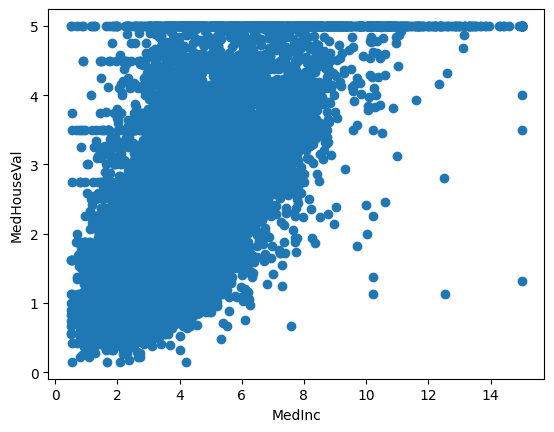

In [91]:
plt.scatter(df['MedInc'],df['MedHouseVal'])
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.show()

In [92]:
df.corr()["MedHouseVal"].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


In [93]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [94]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [95]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [96]:
X_Train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

In [97]:
print(X_Train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [98]:
model=LinearRegression()
model.fit(X_Train,y_train)

LinearRegression()

In [99]:
model.fit(X_Train, y_train)

LinearRegression()

In [100]:
y_pred = model.predict(X_test)

In [101]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)

0.5332001304956553


In [102]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.5757877060324508


In [103]:
print(model.coef_)
print(model.intercept_)

[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
-37.02327770606409


In [104]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

0.5558915986952444


In [105]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
print(comparison.head())

        Actual  Predicted
20046  0.47700   0.719123
3024   0.45800   1.764017
15663  5.00001   2.709659
20484  2.18600   2.838926
9814   2.78000   2.604657


In [106]:
from sklearn.preprocessing import StandardScaler

In [107]:
scaler = StandardScaler()

In [108]:
X_Train_scaled = scaler.fit_transform(X_Train)
X_test_scaled = scaler.transform(X_test)

In [109]:
print(X_Train_scaled[:5])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


In [110]:
from sklearn.linear_model import Ridge

In [111]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_Train_scaled,y_train)

Ridge()

In [112]:
ridge_pred = ridge.predict(X_test_scaled)

In [113]:
ridge_mae=mean_absolute_error(y_test,ridge_pred)
ridge_pred_r2=r2_score(y_test,ridge_pred)
ridge_pred_mse=mean_squared_error(y_test,ridge_pred)
print(ridge_mae)
print(ridge_pred_r2)
print(ridge_pred_mse)

0.5331931195789733
0.5758157428913684
0.5558548589435971


In [114]:
for alpha in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_Train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    print(alpha, mean_absolute_error(y_test, ridge_pred), r2_score(y_test, ridge_pred), mean_squared_error(y_test, ridge_pred))

0.01 0.5332000589081536 0.5757879873121597 0.5558912301037884
0.1 0.5331994146968931 0.5757905180002312 0.5558879138674184
1 0.5331931195789733 0.5758157428913684 0.5558548589435971
10 0.5331379811394743 0.5760599032848371 0.5555349089718647
100 0.5330142193095552 0.5777912763033604 0.553266102223708


In [115]:
for alpha in [100, 200, 500, 1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_Train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)

    print(
        alpha,
        mean_absolute_error(y_test, ridge_pred),
        r2_score(y_test, ridge_pred),
        mean_squared_error(y_test, ridge_pred)
    )

100 0.5330142193095552 0.5777912763033604 0.553266102223708
200 0.5336538595261149 0.5785381179931433 0.5522874341680918
500 0.5388793407129376 0.5765989736899904 0.5548285062730479
1000 0.5493480019623751 0.5681322035002805 0.5659234379463461


In [116]:
ridge = Ridge(alpha=200)
ridge.fit(X_Train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

In [117]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("R²:", ridge_r2)

MAE: 0.5336538595261149
MSE: 0.5522874341680918
R²: 0.5785381179931433


In [118]:
from sklearn.linear_model import Lasso

In [119]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_Train_scaled, y_train)

Lasso(alpha=0.01)

In [120]:
lasso_pred = lasso.predict(X_test_scaled)

In [121]:
lasso_mae=mean_absolute_error(y_test,lasso_pred)
lasso_r2=r2_score(y_test,lasso_pred)
lasso_mse=mean_squared_error(y_test,lasso_pred)
print(lasso_mae)
print(lasso_r2)
print(lasso_mse)

0.5353261423609051
0.5816154300698727
0.5482548967938964


In [122]:
for alpha in [0.001, 0.01, 0.1, 1, 10]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_Train_scaled, y_train)

    lasso_pred = lasso.predict(X_test_scaled)

    print(
        alpha,
        mean_absolute_error(y_test, lasso_pred),
        r2_score(y_test, lasso_pred),
        mean_squared_error(y_test, lasso_pred)
    )

0.001 0.5331447750392391 0.5768562568705682 0.5544913600832686
0.01 0.5353261423609051 0.5816154300698727 0.5482548967938964
0.1 0.6222011605619467 0.48136113250290735 0.6796290284328825
1 0.9060685490007149 -0.00021908714592466794 1.3106960720039365
10 0.9060685490007149 -0.00021908714592466794 1.3106960720039365


In [123]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_Train_scaled, y_train)

print(lasso.coef_)

[ 0.80095744  0.12708701 -0.16275931  0.20620745 -0.         -0.03060176
 -0.79011254 -0.75567379]


In [124]:
print("Linear Regression:")
print(model.coef_)

print("\nRidge:")
print(ridge.coef_)

print("\nLasso:")
print(lasso.coef_)

Linear Regression:
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]

Ridge:
[ 0.84108825  0.13511635 -0.25529395  0.29198939  0.00180926 -0.04129577
 -0.76970985 -0.74065909]

Lasso:
[ 0.80095744  0.12708701 -0.16275931  0.20620745 -0.         -0.03060176
 -0.79011254 -0.75567379]


In [125]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MAE": [mae, ridge_mae, lasso_mae],
    "MSE": [mse, ridge_mse, lasso_mse],
    "R²": [r2, ridge_r2, lasso_r2]
})

comparison.round(4)

,Model,MAE,MSE,R²
0,Linear Regression,0.5332,0.5559,0.5758
1,Ridge,0.5337,0.5523,0.5785
2,Lasso,0.5353,0.5483,0.5816


In [126]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5, random_state=42)

In [127]:
tree.fit(X_Train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [128]:
tree_pred=tree.predict(X_test)

In [129]:
tree_mae=mean_absolute_error(y_test, tree_pred)
tree_r2=r2_score(y_test, tree_pred)
tree_mse=mean_squared_error(y_test, tree_pred)
print(tree_mae)
print(tree_r2)
print(tree_mse)

0.5222592972077786
0.5997321244428706
0.5245146178314735


In [130]:
for depth in [2, 5, 10, 15, 20]:
  tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
  tree.fit(X_Train, y_train)
  tree_pred = tree.predict(X_test)
  print(depth, mean_absolute_error(y_test, tree_pred), r2_score(y_test, tree_pred), mean_squared_error(y_test, tree_pred))


2 0.6600834593469381 0.4244060273337802 0.7542635096031615
5 0.5222592972077786 0.5997321244428706 0.5245146178314735
10 0.4332031802610876 0.6829476865157171 0.4154681981618525
15 0.43748148533329756 0.6460087986104097 0.46387324851920164
20 0.4494260832412055 0.6267584102582241 0.4890991302505296


In [131]:
from sklearn.model_selection import cross_val_score

In [132]:
tree = DecisionTreeRegressor(max_depth=2, random_state=42)

In [134]:
scores = cross_val_score(
    tree,
    X_Train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)

[0.4483262  0.45496014 0.44167828 0.43873648 0.45391363]


In [135]:
print("Average R²:", scores.mean())

Average R²: 0.4475229462228688


In [137]:
for depth in [2, 5, 10, 15, 20]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)

    scores = cross_val_score(
        tree,
        X_Train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(depth, scores.mean())

2 0.4475229462228688
5 0.6198562834590488
10 0.6906257143726601
15 0.6255028593962513
20 0.6074320063626865


In [138]:
tree = DecisionTreeRegressor(max_depth=10, random_state=42)

In [140]:
tree.fit(X_Train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [141]:
tree_pred = tree.predict(X_test)

In [142]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("R²:", tree_r2)

MAE: 0.4332031802610876
MSE: 0.4154681981618525
R²: 0.6829476865157171


In [143]:
from sklearn.ensemble import RandomForestRegressor

In [144]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [145]:
rf.fit(X_Train, y_train)

RandomForestRegressor(random_state=42)

In [148]:
rf_pred=rf.predict(X_test)

In [149]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(rf_mae)
print(rf_mse)
print(rf_r2)

0.32754256845930246
0.2553684927247781
0.8051230593157366


In [151]:
rf_train_pred = rf.predict(X_Train)

rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Training R²:", rf_train_r2)

Training R²: 0.9735726320302575


In [153]:
rf_scores = cross_val_score(
    rf,
    X_Train,
    y_train,
    cv=5,
    scoring="r2"
)

print(rf_scores)
print("Average CV R²:", rf_scores.mean())

[0.80899315 0.79381357 0.80828862 0.80440441 0.8051215 ]
Average CV R²: 0.8041242497453812


In [155]:
for n in [100, 200, 300]:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_Train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(n, scores.mean())

100 0.8041242497453812
200 0.8048573532870817
300 0.8054026607988636


In [157]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_Train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [159]:
rf_train_pred = rf.predict(X_Train)

train_r2 = r2_score(y_train, rf_train_pred)

print("Training R²:", train_r2)

Training R²: 0.9743857138433831


In [161]:
for depth in [5, 10, 15, 20, None]:
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_Train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(depth, scores.mean())

5 0.6673300013411442
10 0.7826465944598385
15 0.8034569708989625
20 0.8054690219780186
None 0.8054026607988636


In [163]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf.fit(X_Train, y_train)

rf_pred = rf.predict(X_test)

In [164]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R²:", rf_r2)

MAE: 0.326950873778433
MSE: 0.2542014783509151
R²: 0.8060136319485871


In [165]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, tree_pred),
        mean_squared_error(y_test, rf_pred)
    ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,MSE,R2
0,Linear Regression,0.533200,0.555892,0.575788
1,Ridge,0.533654,0.552287,0.578538
2,Lasso,0.906069,1.310696,-0.000219
3,Decision Tree,0.433203,0.415468,0.682948
4,Random Forest,0.326951,0.254201,0.806014


In [167]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_Train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

In [168]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, tree_pred),
        mean_squared_error(y_test, rf_pred)
    ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,MSE,R2
0,Linear Regression,0.533200,0.555892,0.575788
1,Ridge,0.533654,0.552287,0.578538
2,Lasso,0.535326,0.548255,0.581615
3,Decision Tree,0.433203,0.415468,0.682948
4,Random Forest,0.326951,0.254201,0.806014


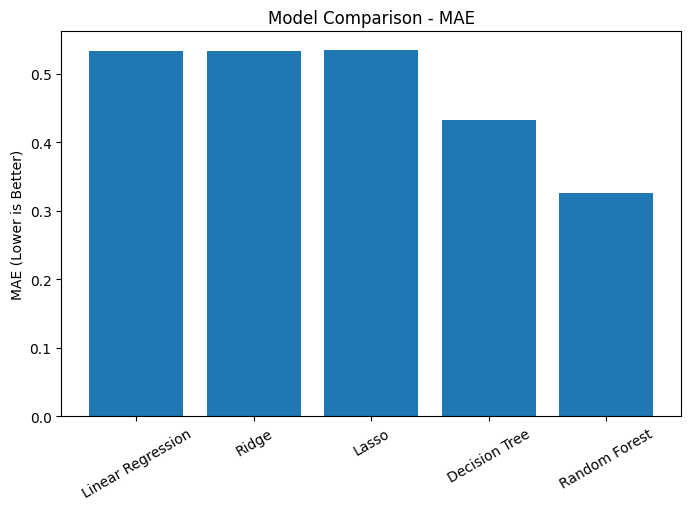

In [169]:
# MAE comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["MAE"])
plt.title("Model Comparison - MAE")
plt.ylabel("MAE (Lower is Better)")
plt.xticks(rotation=30)
plt.show()

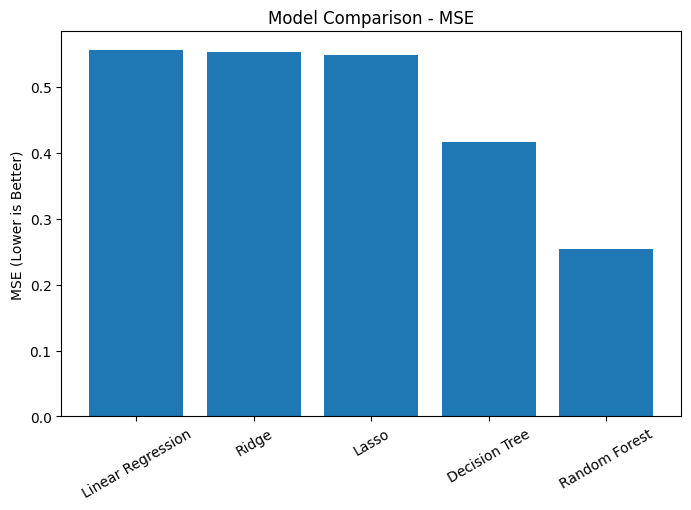

In [170]:
# MSE comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["MSE"])
plt.title("Model Comparison - MSE")
plt.ylabel("MSE (Lower is Better)")
plt.xticks(rotation=30)
plt.show()

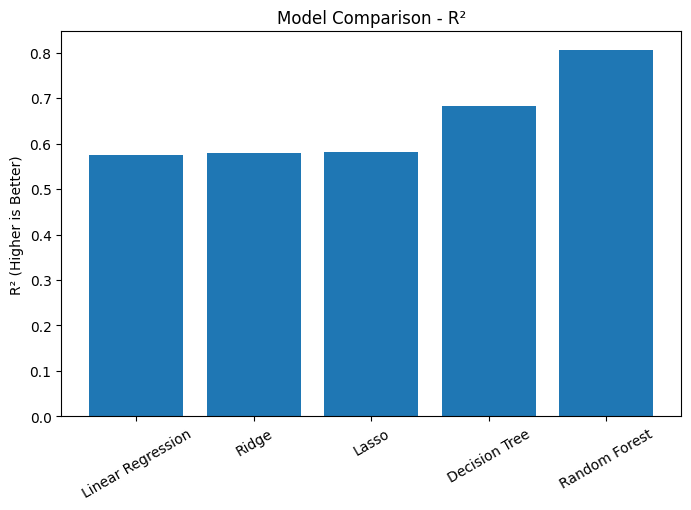

In [171]:
# R² comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["R2"])
plt.title("Model Comparison - R²")
plt.ylabel("R² (Higher is Better)")
plt.xticks(rotation=30)
plt.show()

##Observations
- Dataset: The California Housing dataset contains 20,640 rows and 8 input features used to predict house values.
- Correlation: MedInc had the strongest positive correlation with house value (0.688), indicating that areas with higher median income generally had higher house values.
- Linear Regression: R² = 0.576, meaning the model explained about 57.6% of the variation in house values.
- Ridge Regression: R² = 0.579, showing a slight improvement over Linear Regression after applying regularization.
- Lasso Regression: R² = 0.582. Lasso also reduced the coefficient of Population to 0, showing how Lasso can perform feature selection.
- Decision Tree: R² = 0.683, showing that the tree captured nonlinear relationships better than the linear models.
- Random Forest: R² = 0.806, with the lowest MAE (0.327) and MSE (0.254), making it the best-performing model among the tested models.
- Overall: The results show that tree-based models performed better than linear models for this dataset, with Random Forest giving the strongest prediction performance.

## Conclusion

Different machine learning regression models were trained and evaluated for predicting house values. Among the tested models, Random Forest achieved the best performance with an R² score of 0.806 and the lowest MAE and MSE. This shows that Random Forest was able to capture the relationships in the dataset better than the other models tested.